In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
trader = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed.csv")

# Preview data
print(trader.head())

print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
trader.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [5]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [6]:
trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [7]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [8]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
trader.duplicated().sum()

np.int64(0)

In [11]:
sentiment.duplicated().sum()

np.int64(0)

In [12]:
print(trader.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [13]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


In [10]:
# Convert trader date

trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    dayfirst=True
)

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common Date column
trader['Date'] = trader['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

print("Date conversion successful")

Date conversion successful


In [9]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='str')


In [ ]:
# Merge Data


merged = pd.merge(
    trader,
    sentiment,
    on='Date',
    how='inner'
)

print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [16]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date']


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trader = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed.csv")

trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True)
sentiment['date'] = pd.to_datetime(sentiment['date'])

trader['Date'] = trader['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

merged = pd.merge(trader, sentiment, on="Date", how="inner")

In [9]:
# Profit Analysis
print(
    merged.groupby('classification')['Closed PnL'].mean()
)


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [10]:
# Trade Count
print(
    merged.groupby(['classification', 'Side']).size()
)

classification  Side
Extreme Fear    BUY     10935
                SELL    10465
Extreme Greed   BUY     17940
                SELL    22052
Fear            BUY     30270
                SELL    31567
Greed           BUY     24576
                SELL    25727
Neutral         BUY     18969
                SELL    18717
dtype: int64


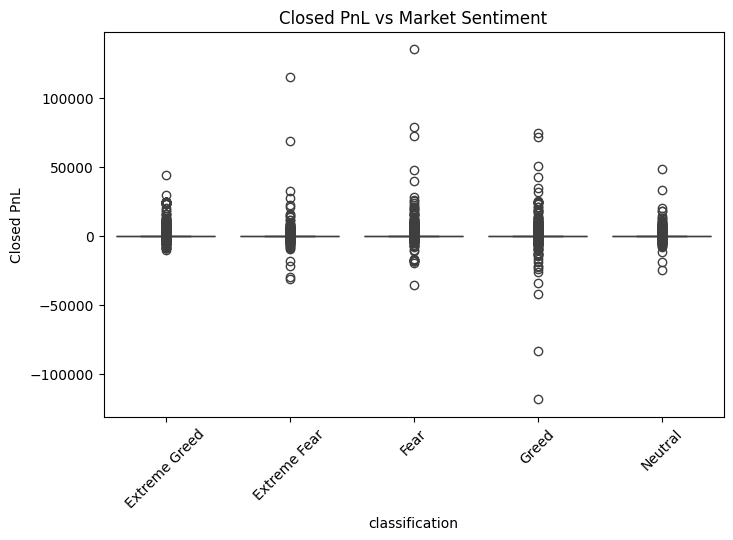

In [11]:
# Chart
plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Closed PnL vs Market Sentiment")

plt.xticks(rotation=45)

plt.show()

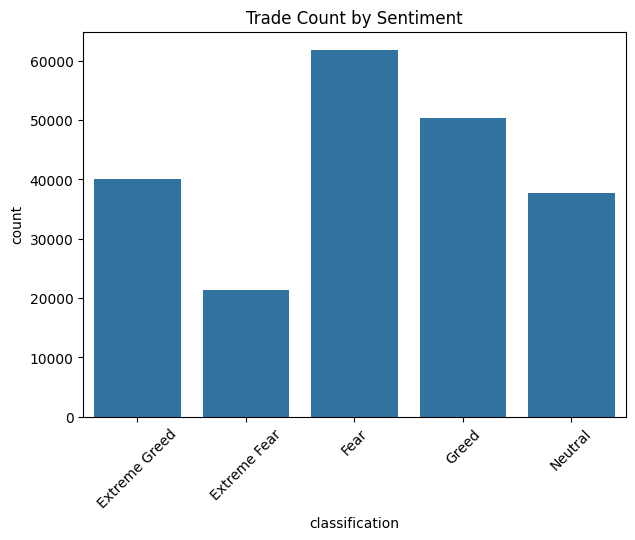

In [12]:
# Trade count chart

plt.figure(figsize=(7,5))

sns.countplot(
    x='classification',
    data=merged
)

plt.title("Trade Count by Sentiment")

plt.xticks(rotation=45)

plt.show()

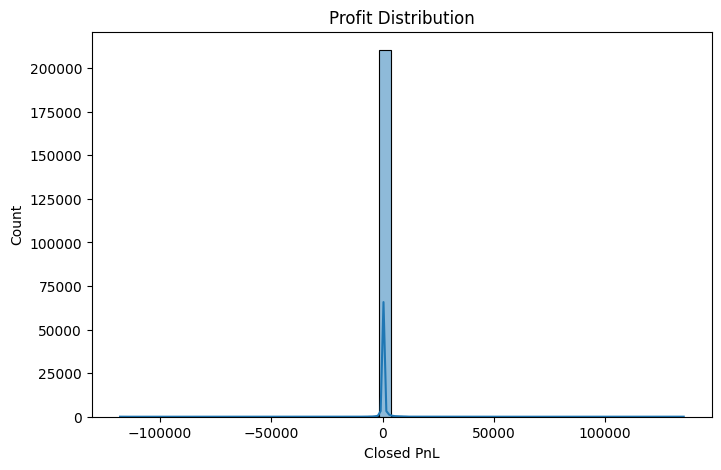

In [13]:
# Profit distribution chart

plt.figure(figsize=(8,5))

sns.histplot(
    merged['Closed PnL'],
    bins=50,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

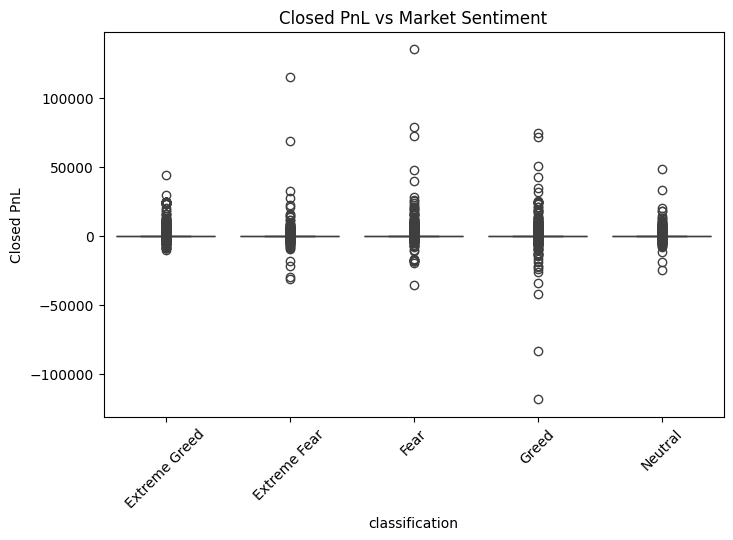

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Closed PnL vs Market Sentiment")

plt.xticks(rotation=45)

# Save chart
plt.savefig("../outputs/pnl_vs_sentiment.png")

plt.show()

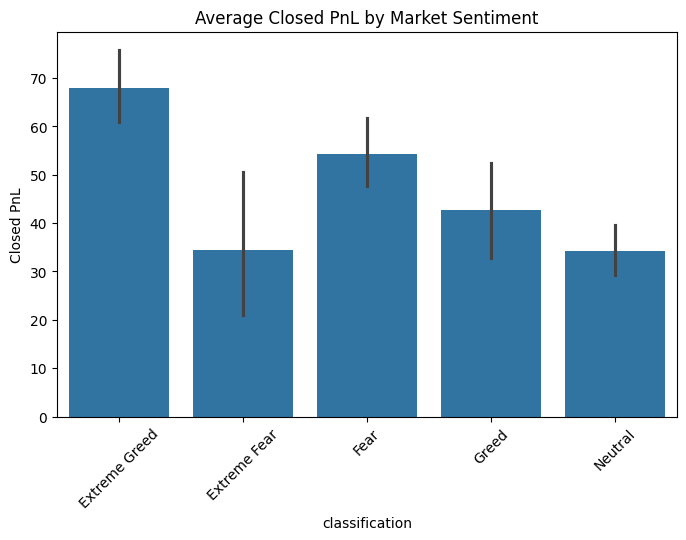

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Closed PnL',
    data=merged,
    estimator='mean'
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xticks(rotation=45)

plt.show()

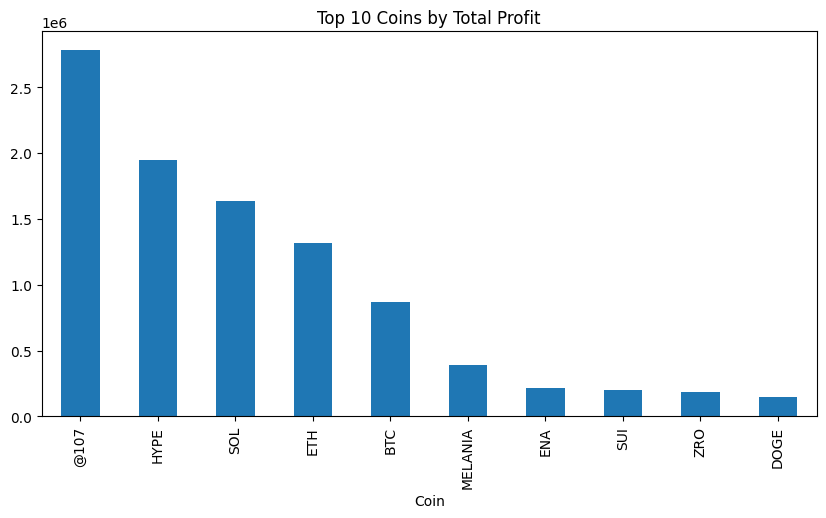

In [17]:
top_coin = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top_coin.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Coins by Total Profit")

plt.show()

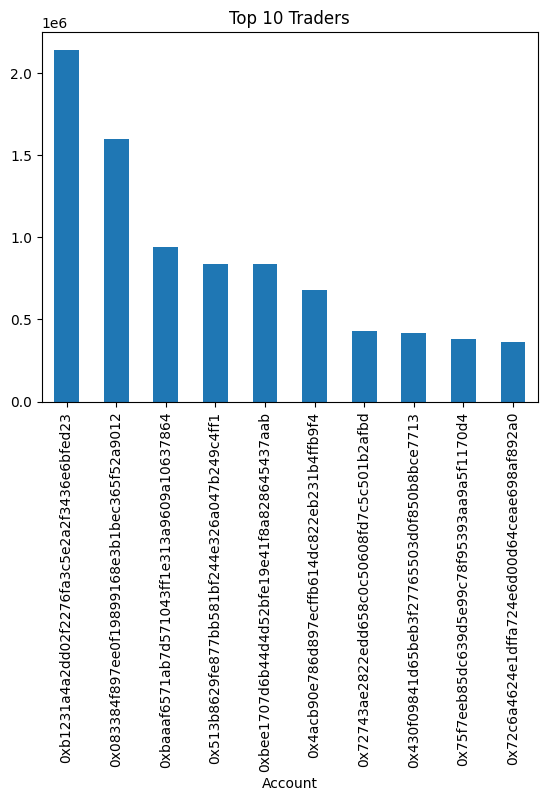

In [19]:
top = merged.groupby("Account")["Closed PnL"].sum()

top.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Traders")

plt.show()

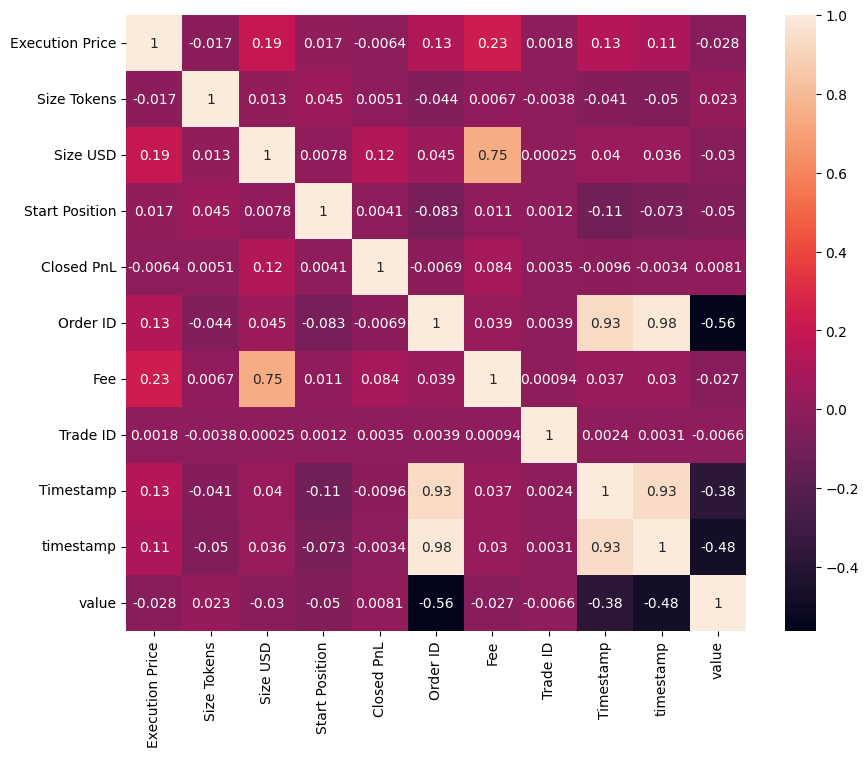

In [20]:
numeric = merged.select_dtypes(include='number')

plt.figure(figsize=(10,8))

sns.heatmap(numeric.corr(), annot=True)

plt.show()